# Customer Churn Analysis
In this notebook, we perform data cleaning and Exploratory Data Analysis (EDA) on our 20,000+ customer records to identify key drivers of churn.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configure plot styles
sns.set_theme(style="whitegrid")

# Load the dataset
df = pd.read_csv('customer_data.csv')
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (21500, 12)


,CustomerID,Gender,SeniorCitizen,Partner,Dependents,Tenure,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,CUST-100000,Male,0,Yes,No,68,Two year,No,Credit card (automatic),36.44,2395.31,No
1,CUST-100001,Male,0,Yes,Yes,7,One year,Yes,Mailed check,42.92,317.86,Yes
2,CUST-100002,Female,0,Yes,No,19,Two year,Yes,Mailed check,51.49,946.87,No
3,CUST-100003,Male,0,No,Yes,71,Two year,No,Electronic check,76.52,5629.21,No
4,CUST-100004,Male,0,Yes,No,33,Two year,No,Mailed check,92.83,2831.45,No


## Data Cleaning
We will check for missing values and ensure data types are correct.

In [5]:
# Check for missing values
print(df.isnull().sum())

# Drop the intentionally injected nulls in TotalCharges
df = df.dropna()
print(f"Dataset shape after cleaning: {df.shape}")

CustomerID           0
Gender               0
SeniorCitizen        0
Partner              0
Dependents           0
Tenure               0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        50
Churn                0
dtype: int64
Dataset shape after cleaning: (21450, 12)


## Exploratory Data Analysis (EDA)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_24580\3636739751.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df, palette='Set2')


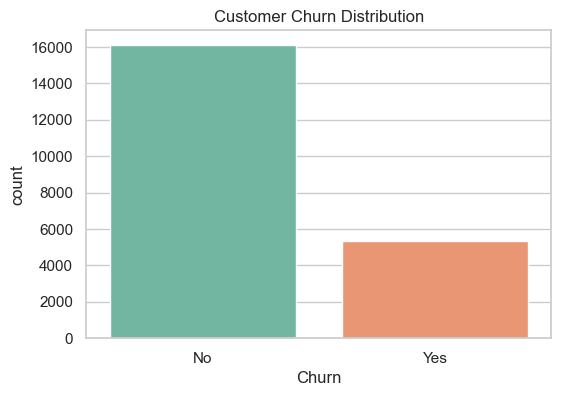

In [6]:
# 1. Overall Churn Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=df, palette='Set2')
plt.title('Customer Churn Distribution')
plt.show()

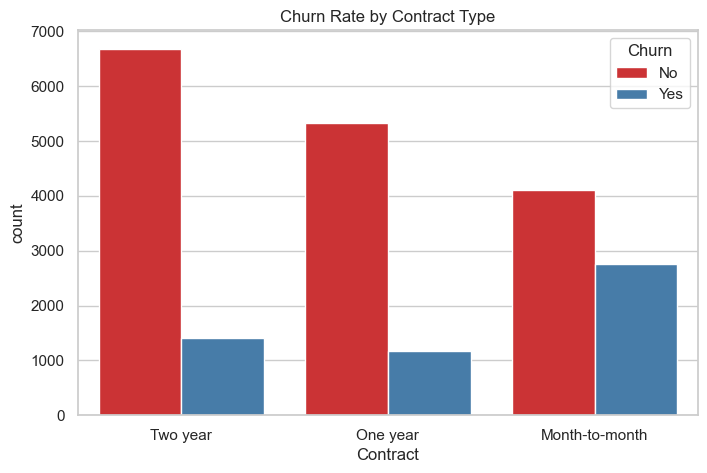

In [7]:
# 2. Churn by Contract Type
plt.figure(figsize=(8, 5))
sns.countplot(x='Contract', hue='Churn', data=df, palette='Set1')
plt.title('Churn Rate by Contract Type')
plt.show()

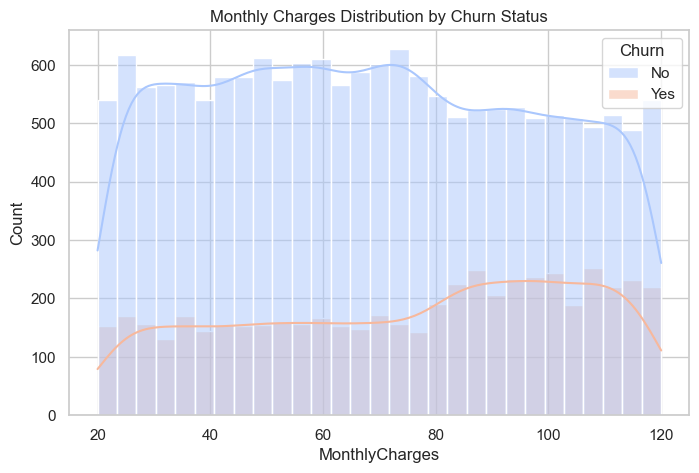

In [8]:
# 3. Monthly Charges Distribution (Churn vs Retained)
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='MonthlyCharges', hue='Churn', kde=True, palette='coolwarm')
plt.title('Monthly Charges Distribution by Churn Status')
plt.show()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_24580\2706182943.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='Tenure', data=df, palette='Set3')


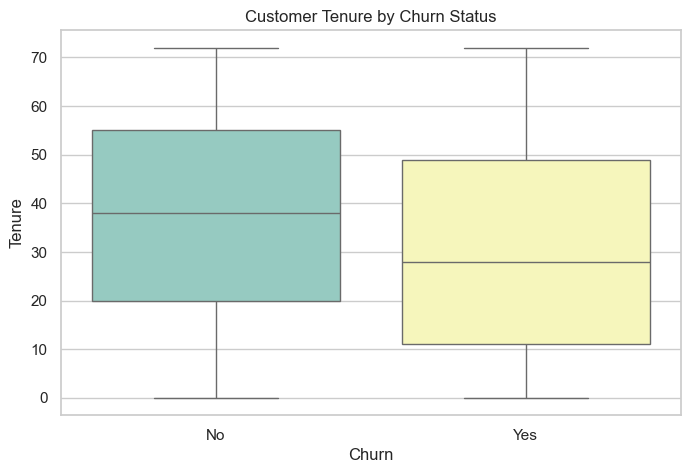

In [9]:
# 4. Tenure vs Churn
plt.figure(figsize=(8, 5))
sns.boxplot(x='Churn', y='Tenure', data=df, palette='Set3')
plt.title('Customer Tenure by Churn Status')
plt.show()

## Recommendations
Based on the EDA:
1. **Focus on Month-to-Month Contracts**: These customers have the highest churn rate. We should offer incentives to upgrade to 1-year contracts.
2. **Review Pricing for High Monthly Charges**: Customers with high monthly charges are more likely to churn.
3. **Early Retention**: Most churn happens in the early tenure months. Introduce better onboarding processes.